# TME FORWARD MUSIC

* Songs without UPC will be excluded.
* Songs without ISCR will be granted synthetic ISCR, which is "Song - Artist".

In [56]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [57]:
import pandas as pd
from config import (
    BASE_PATH, 
    TOP_N_SONGS, 
    TOP_N_ALBUMS, 
    OUTPUT_SONG_REPORT_PATH, 
    OUTPUT_ALBUM_REPORT_PATH,
    OUTPUT_SONG_REPORT_PATH_MONTHLY,
    OUTPUT_ALL_REPORT_PATH,
    OUTPUT_CHART_PATH
)
from pipeline import run_etl_pipeline, clean_and_unify_data
from reporting import generate_song_report, generate_album_report, generate_song_report_by_year
import plotting
import os

In [58]:
print(BASE_PATH, '\n', OUTPUT_SONG_REPORT_PATH)

/Users/chu-chun/Mirror/Eva/input/TME/ 
 ../output/FORWARD/TME_Song_Report_Forward.xlsx


In [59]:
# Run the ETL pipeline to ingest files
df_raw = run_etl_pipeline(BASE_PATH)

# Clean dates, unify platforms, and standardize metadata names
df_cleaned = clean_and_unify_data(df_raw)
df_cleaned.info()

/Users/chu-chun/Mirror/Eva/analysis/pipeline.py:118: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_raw = pd.concat(all_data, ignore_index=True)


<class 'pandas.core.frame.DataFrame'>
Index: 288910 entries, 165378 to 112665
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   YearMonth        288910 non-null  object 
 1   Platform         288910 non-null  object 
 2   Song             288910 non-null  object 
 3   ISRC             288910 non-null  object 
 4   Artist           288910 non-null  object 
 5   Album            286034 non-null  object 
 6   UPC              288888 non-null  object 
 7   Revenue          288910 non-null  float64
 8   Total_Clicks     288910 non-null  object 
 9   source_file      288910 non-null  object 
 10  standard_song    288910 non-null  object 
 11  standard_artist  288910 non-null  object 
dtypes: float64(1), object(11)
memory usage: 28.7+ MB


In [60]:
# see where TW songs are
df_tw = df_cleaned[df_cleaned['ISRC'].str.startswith('TW', na=False)]
df_tw.groupby('source_file').agg('size')

source_file
aiting_song_outside_detail_CON02-TME00-20230731-0006_284097627_20240201-20240229-0530041126.xlsx     135
mv_outside_detail_ver_CON02-TME00-20230731-0006_kg_309273468_20250501-20250531-0621022436.xlsx      1661
mv_outside_detail_ver_CON02-TME00-20230731-0006_qq_327765411_20260301-20260331-0522204557.xlsx      1193
dtype: int64

In [61]:
# Exclude Taiwan songs (ISRC starting with 'TW') and drop empty ISRC
df_cleaned = df_cleaned[~df_cleaned['ISRC'].str.startswith('TW', na=False)]

In [62]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 285921 entries, 165378 to 112665
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   YearMonth        285921 non-null  object 
 1   Platform         285921 non-null  object 
 2   Song             285921 non-null  object 
 3   ISRC             285921 non-null  object 
 4   Artist           285921 non-null  object 
 5   Album            285899 non-null  object 
 6   UPC              285899 non-null  object 
 7   Revenue          285921 non-null  float64
 8   Total_Clicks     285921 non-null  object 
 9   source_file      285921 non-null  object 
 10  standard_song    285921 non-null  object 
 11  standard_artist  285921 non-null  object 
dtypes: float64(1), object(11)
memory usage: 28.4+ MB


## Investigate NA data

In [63]:
# calculate NA
is_missing = df_cleaned.isna() | (df_cleaned == '') | df_cleaned.astype(str).apply(lambda s: s.str.lower() == 'nan')

missing_summary = pd.DataFrame({
    '缺失值總計 (含空字串/\'nan\')': is_missing.sum(),
    '缺失值比例 (%)': (is_missing.mean() * 100).round(2)
})

print("\n--- 完整缺失值統計 (含空字串與 'nan' 字串) ---")
display(missing_summary.sort_values(by='缺失值總計 (含空字串/\'nan\')', ascending=False))


--- 完整缺失值統計 (含空字串與 'nan' 字串) ---


,缺失值總計 (含空字串/'nan'),缺失值比例 (%)
Album,22,0.01
UPC,22,0.01
YearMonth,0,0.00
Platform,0,0.00
Song,0,0.00
ISRC,0,0.00
Artist,0,0.00
Revenue,0,0.00
Total_Clicks,0,0.00
source_file,0,0.00


In [64]:
df_cleaned.head()

,YearMonth,Platform,Song,ISRC,Artist,Album,UPC,Revenue,Total_Clicks,source_file,standard_song,standard_artist
165378,2024-01,UltimateMusic,锦锈乾坤,HKG631876005,郑少秋,书剑恩仇录,UPC-4715202900480,0.016062,1,aiting_song_outside_detail_CON02-TME00-2023073...,锦锈乾坤,郑少秋
166843,2024-01,Kugou,郎归晚(Live),HKG631895046,汪明荃,汪明荃演唱会,UPC-4715202900978,8.629039,516,song_outside_detail_CON02-TME00-20230731-0006_...,郎归晚(Live),汪明荃
166842,2024-01,Kugou,千王群英会(Live),HKG631895045,汪明荃,汪明荃演唱会,UPC-4715202900978,0.138293,114,song_outside_detail_CON02-TME00-20230731-0006_...,千王群英会(Live),汪明荃
166841,2024-01,Kugou,用爱将心偷(Live),HKG631895044,汪明荃,汪明荃演唱会,UPC-4715202900978,28.407109,1565,song_outside_detail_CON02-TME00-20230731-0006_...,用爱将心偷(Live),汪明荃
166840,2024-01,Kugou,笑看风云(Live),HKG631895043,郑少秋,汪明荃演唱会,UPC-4715202900978,124.408332,40075,song_outside_detail_CON02-TME00-20230731-0006_...,笑看风云(Live),郑少秋


In [65]:
missing_upc = df_cleaned[df_cleaned['UPC'].isna()]
missing_upc.head()

,YearMonth,Platform,Song,ISRC,Artist,Album,UPC,Revenue,Total_Clicks,source_file,standard_song,standard_artist
245291,2025-05,Kugou,陈氏情歌,陈氏情歌 - 郭晓东,郭晓东,NaN,NaN,0.000739,1,mv_outside_detail_ver_CON02-TME00-20230731-000...,陈氏情歌,郭晓东
245290,2025-05,Kugou,陈氏情歌,陈氏情歌 - 郭晓东,郭晓东,NaN,NaN,0.000739,1,mv_outside_detail_ver_CON02-TME00-20230731-000...,陈氏情歌,郭晓东
245289,2025-05,Kugou,陈氏情歌,陈氏情歌 - 郭晓东,郭晓东,NaN,NaN,0.000000,0,mv_outside_detail_ver_CON02-TME00-20230731-000...,陈氏情歌,郭晓东
245288,2025-05,Kugou,思念你,思念你 - ZEN俊倩,Zen 俊倩,NaN,NaN,0.000000,0,mv_outside_detail_ver_CON02-TME00-20230731-000...,思念你,Zen 俊倩
245287,2025-05,Kugou,思念你,思念你 - ZEN俊倩,Zen 俊倩,NaN,NaN,0.000000,0,mv_outside_detail_ver_CON02-TME00-20230731-000...,思念你,Zen 俊倩


In [66]:
# identify NA data in source file
df_cleaned[df_cleaned['UPC'].isna()].groupby('source_file').size()


source_file
mv_outside_detail_ver_CON02-TME00-20230731-0006_kg_309273468_20250501-20250531-0621022436.xlsx    11
mv_outside_detail_ver_CON02-TME00-20230731-0006_qq_327765411_20260301-20260331-0522204557.xlsx    11
dtype: int64

## Check song and artist name discrepancy

In [67]:
temp = df_cleaned.groupby(['ISRC', 'UPC'])['Song'].unique()
result = temp[temp.apply(len) > 1]
song_mismatch = pd.DataFrame(result).reset_index()
song_mismatch

,ISRC,UPC,Song
0,HKG631883001,UPC-4715202900923,"[我祇有期待, 我只有期待]"
1,HKG631883008,UPC-4715202900923,"[祇对着一个影, 只对着一个影]"
2,HKG631896030,UPC-4715202900985,"[男儿着眼天地开, 男儿着眼天地间]"


In [68]:
temp = df_cleaned.groupby(['ISRC', 'UPC'])['Artist'].unique()
result = temp[temp.apply(len) > 1]
artist_mismatch = pd.DataFrame(result).reset_index()
artist_mismatch

,ISRC,UPC,Artist
0,HKG631862002,UPC-4715202901333,"[梁醒波,朱少坡, 朱少坡,梁醒波]"


## Monthly Revenue Trend
Plot total monthly revenue and show MoM Growth Percentage.

Monthly Revenue and Clicks Summary:


/var/folders/hg/5j5mzy6x2ps4l676cl2hpt_r0000gn/T/ipykernel_70062/3690182989.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .pct_change()


,YearMonth,clicks,Click_MoM_Growth,revenue,Rev_MoM_Growth
0,2024-01,41898461,N/A,209852.907614,N/A
1,2024-02,30164684,-28.01%,181187.764300,-13.66%
2,2024-03,34689601,15.00%,172953.388391,-4.54%
3,2024-04,33077193,-4.65%,156990.340699,-9.23%
4,2024-05,33142087,0.20%,158068.380902,0.69%
5,2024-06,30624298,-7.60%,152164.607659,-3.73%
6,2024-07,31095075,1.54%,140728.021413,-7.52%
7,2024-08,31079126,-0.05%,141927.807687,0.85%
8,2024-09,30021739,-3.40%,141598.080387,-0.23%
9,2024-10,31267332,4.15%,141383.415110,-0.15%


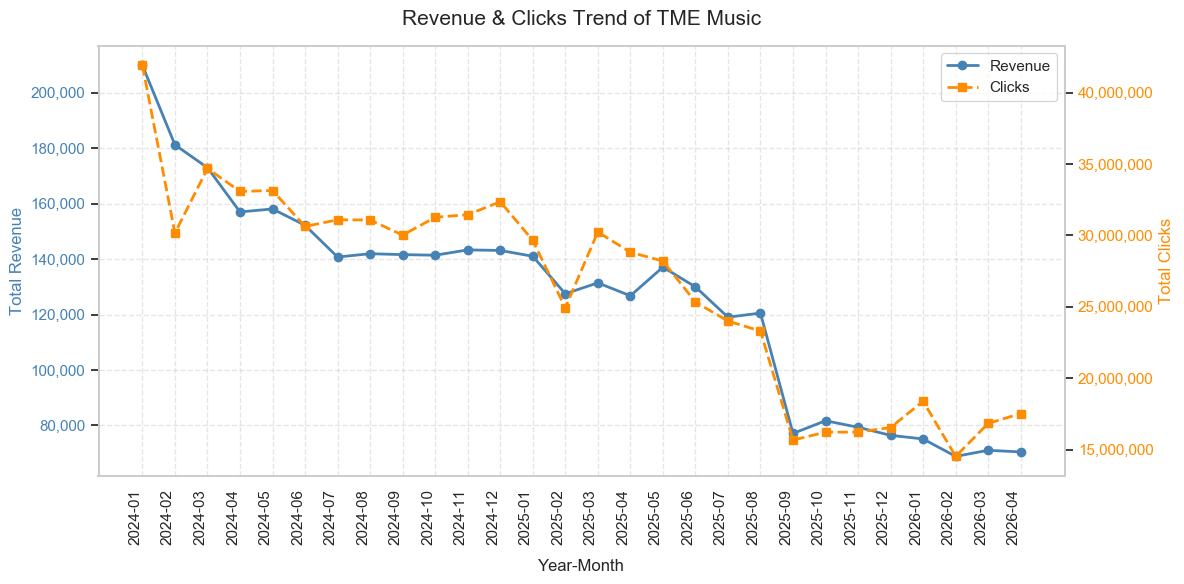

In [69]:
revenue_by_month = (
    df_cleaned.groupby('YearMonth')
    .agg(revenue=('Revenue', 'sum'), clicks=('Total_Clicks', 'sum'))
    .reset_index()
)
revenue_by_month['Rev_MoM_Growth'] = (
    revenue_by_month['revenue']
    .pct_change()
    .apply(lambda x: f"{x:.2%}" if pd.notnull(x) else "N/A")
)

revenue_by_month['Click_MoM_Growth'] = (
    revenue_by_month['clicks']
    .pct_change()
    .apply(lambda x: f"{x:.2%}" if pd.notnull(x) else "N/A")
)

new_order = ['YearMonth', 'clicks', 'Click_MoM_Growth', 'revenue','Rev_MoM_Growth']
revenue_by_month = revenue_by_month[new_order]
print("Monthly Revenue and Clicks Summary:")
display(revenue_by_month)

# Plot revenue trend line graph and Save to folder
chart_filename = "TME_Revenue_Clicks_Trend.png"
save_file_path = os.path.join(OUTPUT_CHART_PATH, chart_filename)

plotting.plot_revenue_clicks_trend(revenue_by_month, save_path=save_file_path)

## Filter for Specific Analysis Period
Filter the dataset for the designated target period (e.g. 2024-01 to 2026-03).

In [70]:
START_MONTH = "2023-01"
END_MONTH = "2026-06"

df_filtered = df_cleaned[
    (df_cleaned['YearMonth'] >= START_MONTH) & 
    (df_cleaned['YearMonth'] <= END_MONTH)
]
print(f"Filtered dataset from {START_MONTH} to {END_MONTH} contains {len(df_filtered)} rows.")

Filtered dataset from 2023-01 to 2026-06 contains 285921 rows.


## Top Songs Share & Pie Charts

In [71]:
df_filtered.head()

,YearMonth,Platform,Song,ISRC,Artist,Album,UPC,Revenue,Total_Clicks,source_file,standard_song,standard_artist
165378,2024-01,UltimateMusic,锦锈乾坤,HKG631876005,郑少秋,书剑恩仇录,UPC-4715202900480,0.016062,1,aiting_song_outside_detail_CON02-TME00-2023073...,锦锈乾坤,郑少秋
166843,2024-01,Kugou,郎归晚(Live),HKG631895046,汪明荃,汪明荃演唱会,UPC-4715202900978,8.629039,516,song_outside_detail_CON02-TME00-20230731-0006_...,郎归晚(Live),汪明荃
166842,2024-01,Kugou,千王群英会(Live),HKG631895045,汪明荃,汪明荃演唱会,UPC-4715202900978,0.138293,114,song_outside_detail_CON02-TME00-20230731-0006_...,千王群英会(Live),汪明荃
166841,2024-01,Kugou,用爱将心偷(Live),HKG631895044,汪明荃,汪明荃演唱会,UPC-4715202900978,28.407109,1565,song_outside_detail_CON02-TME00-20230731-0006_...,用爱将心偷(Live),汪明荃
166840,2024-01,Kugou,笑看风云(Live),HKG631895043,郑少秋,汪明荃演唱会,UPC-4715202900978,124.408332,40075,song_outside_detail_CON02-TME00-20230731-0006_...,笑看风云(Live),郑少秋


In [72]:
revenue_by_song = (
    df_filtered
    .groupby(['UPC', 'ISRC'])
    .agg(
        album=('Album', 'first'),
        song=('standard_song', 'first'),
        artist=('standard_artist', 'first'),
        revenue=('Revenue', 'sum'),
        clicks=('Total_Clicks', 'sum')
    )
    .reset_index()
)
revenue_by_song = revenue_by_song.sort_values('revenue', ascending=False)

Top 10 songs contribute to 74.89% of total revenue.


,UPC,ISRC,album,song,artist,revenue,clicks,rev_share,click_share
551,UPC-4715202900930,HKG631895001,笑看风云,笑看风云,郑少秋,1.098876e+06,215730315,0.312499,0.292558
392,UPC-4715202900800,HKG631892001,我是情痴·随缘,随缘,温兆伦,4.233959e+05,68497643,0.120405,0.092892
496,UPC-4715202900909,HKG631892001,投入生命,随缘,温兆伦,4.077443e+05,75084237,0.115954,0.101824
200,UPC-4715202900633,HKG631882039,万水千山总是情 电视剧原声带,万水千山总是情,汪明荃,1.955994e+05,50588017,0.055625,0.068604
241,UPC-4715202900671,HKG631882039,金曲精选,万水千山总是情,汪明荃,1.328907e+05,40822243,0.037792,0.05536
473,UPC-4715202900879,HKG631893007,大时代,摘下满天星,郑少秋,1.289598e+05,23110428,0.036674,0.031341
505,UPC-4715202900916,HKG631894001,天边洒的不是雨,缘份,陈松伶,6.557750e+04,15113934,0.018649,0.020496
908,UPC-4715202901241,HKG631895019,国语最佳精选辑,天地情缘,温兆伦,6.185979e+04,14046427,0.017592,0.019049
618,UPC-4715202900985,HKG631896029,天地男儿,从不放弃,郑少秋,6.129147e+04,9453679,0.017430,0.01282
832,UPC-4715202901173,HKG631878001,小李飞刀,小李飞刀,罗文,5.737533e+04,10100543,0.016316,0.013698


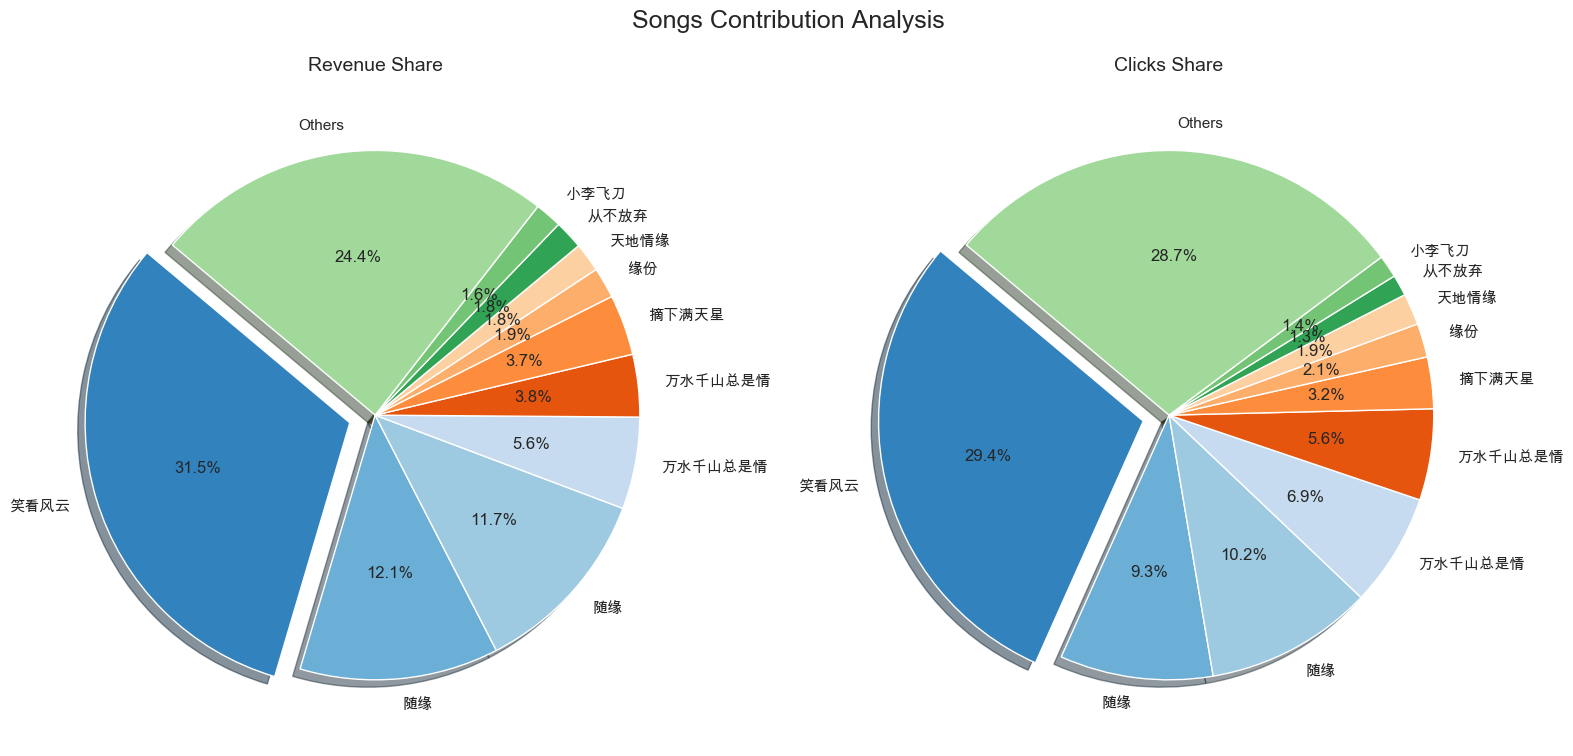

In [73]:
total_rev = revenue_by_song['revenue'].sum()
total_clicks = revenue_by_song['clicks'].sum()

revenue_by_song_top = revenue_by_song.head(TOP_N_SONGS).copy()
revenue_by_song_top['rev_share'] = revenue_by_song_top['revenue'] / total_rev
revenue_by_song_top['click_share'] = revenue_by_song_top['clicks'] / total_clicks
top_song_list = revenue_by_song_top['ISRC'].tolist()

print(f"Top {TOP_N_SONGS} songs contribute to {revenue_by_song_top['rev_share'].sum():.2%} of total revenue.")
display(revenue_by_song_top)

# Side-by-side pie charts for revenue & clicks contribution
top_song_detail = revenue_by_song.head(TOP_N_SONGS).copy()[['song', 'revenue', 'clicks']]
other_songs_rev = revenue_by_song[~revenue_by_song['ISRC'].isin(top_song_list)]['revenue'].sum()
other_songs_clicks = revenue_by_song[~revenue_by_song['ISRC'].isin(top_song_list)]['clicks'].sum()

others_row = pd.DataFrame([{
    'song': 'Others',
    'revenue': other_songs_rev,
    'clicks': other_songs_clicks
}])

df_pie = pd.concat([top_song_detail, others_row], ignore_index=True)

pie_chart_filename = "Song_Contribution_Pie.png"
save_pie_path = os.path.join(OUTPUT_CHART_PATH, pie_chart_filename)
plotting.plot_pie_charts(df_pie, save_path=save_pie_path)

## Generate Song Report
Aggregates, pivots, and exports monthly metrics to Excel.

In [74]:
song_final = generate_song_report(df_filtered, OUTPUT_SONG_REPORT_PATH_MONTHLY)
song_final.head()

/Users/chu-chun/Mirror/Eva/analysis/reporting.py:28: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  song_pivot = revenue_by_song_per_month.pivot_table(


Song report exported successfully to: ../output/FORWARD/TME_Song_Report_Monthly_Forward.xlsx


,ISRC,song,artist,UPC,album,total_click,total_revenue,2024-01_clicks,2024-01_revenue,2024-02_clicks,...,2025-12_clicks,2025-12_revenue,2026-01_clicks,2026-01_revenue,2026-02_clicks,2026-02_revenue,2026-03_clicks,2026-03_revenue,2026-04_clicks,2026-04_revenue
0,HKG631895001,笑看风云,郑少秋,UPC-4715202900930,笑看风云,215730315,1.098876e+06,12551280,66241.968418,9789967,...,0,0.000000,2390068,5328.494253,1781473,3760.102854,1903305,3251.710876,3009001,6597.125502
1,HKG631892001,随缘,温兆伦,UPC-4715202900800,我是情痴·随缘,68497643,4.233959e+05,7333158,47152.967315,4029332,...,1873578,11325.700960,1811273,9320.687824,1572396,9382.119456,1693831,8760.517125,1715161,8498.565327
2,HKG631892001,随缘,温兆伦,UPC-4715202900909,投入生命,75084237,4.077443e+05,6050976,31024.625351,3382755,...,2412381,11487.407443,2404375,10381.962677,1873381,9836.923195,2323522,10108.575414,2332945,9913.993457
3,HKG631882039,万水千山总是情,汪明荃,UPC-4715202900633,万水千山总是情 电视剧原声带,50588017,1.955994e+05,2161371,7674.824207,2048345,...,1304120,6023.323827,1044828,5159.672531,870320,4985.058082,955162,4842.801410,962915,4601.108473
4,HKG631882039,万水千山总是情,汪明荃,UPC-4715202900671,金曲精选,40822243,1.328907e+05,1661393,5215.694363,1431046,...,1012740,3667.515475,1026187,3756.540136,823857,3365.033480,945043,3454.489675,903543,3351.519916


## Monthly Revenue Trend for Top Songs

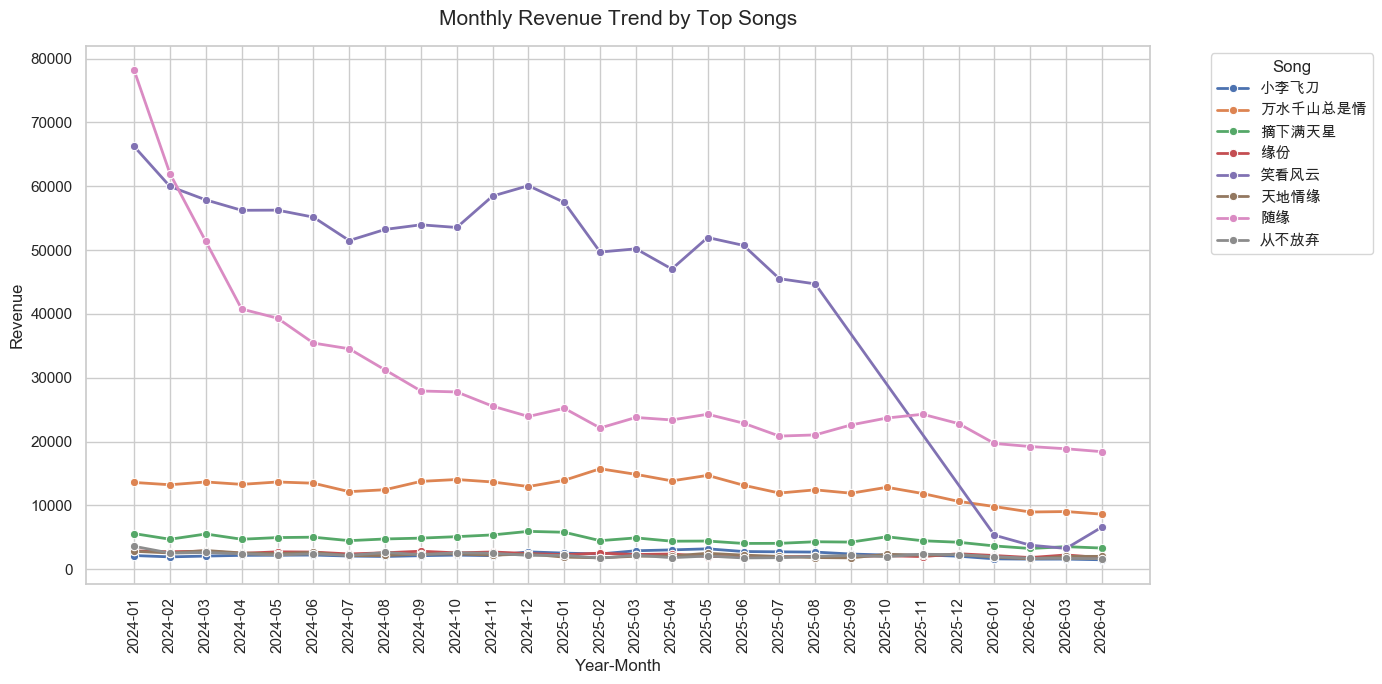

In [75]:
revenue_by_song_per_month = (
    df_filtered
    .groupby(['ISRC', 'YearMonth'])
    .agg(
        song=('standard_song', 'first'),
        revenue=('Revenue', 'sum')
    )
    .reset_index()
)
monthly_revenue_top_song = revenue_by_song_per_month[revenue_by_song_per_month['ISRC'].isin(top_song_list)].sort_values('YearMonth')

song_trend_path = os.path.join(OUTPUT_CHART_PATH, "Monthly_Revenue_by_Top_Songs.png")
plotting.plot_monthly_revenue_by_top_songs(monthly_revenue_top_song, TOP_N_SONGS, save_path=song_trend_path)

## Revenue by Platform

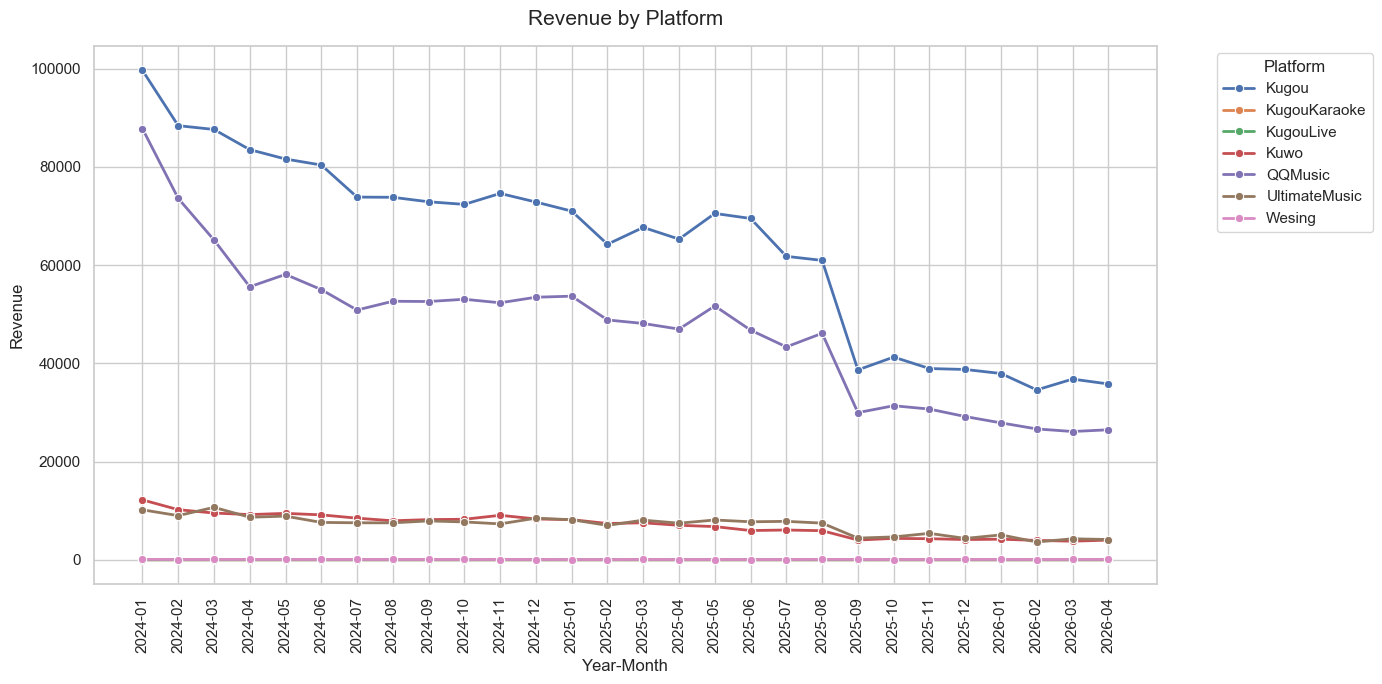

In [76]:
revenue_by_platform_per_month = (
    df_filtered
    .groupby(['ISRC', 'YearMonth', 'Platform'])
    .agg(revenue=('Revenue', 'sum'))
    .reset_index()
)
revenue_by_platform = (
    revenue_by_platform_per_month
    .groupby(['YearMonth', 'Platform'])
    .agg(revenue=('revenue', 'sum'))
    .reset_index()
)

platform_trend_path = os.path.join(OUTPUT_CHART_PATH, "Revenue_by_Platform.png")
plotting.plot_revenue_by_platform(revenue_by_platform, save_path=platform_trend_path)

## Generate Album Report & Plot Revenue by Album

In [77]:
# Generate Excel report for Albums
# album_final = generate_album_report(df_filtered, OUTPUT_ALBUM_REPORT_PATH)
# display(album_final.head())

# Find top albums contribute to total revenue
revenue_by_album = (
    df_filtered
    .groupby(['UPC'])
    .agg(
        album=('Album', 'first'),
        revenue=('Revenue', 'sum')
    )
    .reset_index()
)
revenue_by_album = revenue_by_album.sort_values('revenue', ascending=False)
print(f"Top {TOP_N_ALBUMS} albums contribute to {revenue_by_album['revenue'].head(TOP_N_ALBUMS).sum()/revenue_by_album['revenue'].sum():.2%} of total revenue.")

# Plot monthly trend lines for the top albums
top_n_album_list = revenue_by_album['UPC'].head(TOP_N_ALBUMS).tolist()
revenue_by_album_per_month = (
    df_filtered
    .groupby(['UPC', 'YearMonth'])
    .agg(
        album=('Album', 'first'),
        revenue=('Revenue', 'sum')
    )
    .reset_index()
)
top_album_trend = revenue_by_album_per_month[
    revenue_by_album_per_month['UPC'].isin(top_n_album_list)
]

album_trend_path = os.path.join(OUTPUT_CHART_PATH, "Revenue_by_Album.png")
# plotting.plot_revenue_by_album(top_album_trend, save_path=album_trend_path)

Top 10 albums contribute to 81.65% of total revenue.


## Generate in one Excel file

In [78]:
sheets_dict = {
    'Monthly_Rev_Click': song_final,
    'Total_Revenue': revenue_by_month,
    'Top_10': revenue_by_song_top,
    'Missing_UPC': missing_upc,
    'Song_mismatch': song_mismatch,
    'Artist_mismatch': artist_mismatch,
}

with pd.ExcelWriter(OUTPUT_ALL_REPORT_PATH, engine='openpyxl') as writer:
    for sheet_name, df in sheets_dict.items():
        df.to_excel(writer, sheet_name=sheet_name, index=False)


## Compare Two Files

In [79]:
FILE1_PATH = "/Users/chu-chun/Mirror/Eva/output/FORWARD/TME_Song_Report_Monthly_Forward.xlsx"
FILE2_PATH = "/Users/chu-chun/Mirror/Eva/output/FORWARD/TME_Song_Report_202401_202603_舊版.xlsx"

df1 = pd.read_excel(FILE1_PATH)
df2 = pd.read_excel(FILE2_PATH)

# 合併 col1 + col2 形成比較用 key
df1["key"] = df1["ISRC"].astype(str) + "_" + df1["UPC"].astype(str)
df2["key"] = df2["ISRC"].astype(str) + "_" + df2["song"].astype(str)

result = df1[["key"]].merge(
    df2[["key"]],
    on="key",
    how="outer",
    indicator=True
)

print(result["_merge"].value_counts())

only_in_file1 = result[result["_merge"] == "left_only"]
only_in_file2 = result[result["_merge"] == "right_only"]

_merge
both          1075
left_only        1
right_only       0
Name: count, dtype: int64


In [80]:
print(df1["key"].duplicated().sum())
print(df2["key"].duplicated().sum())

0
0


In [81]:
print("df1 rows =", len(df1))
print("df1 unique =", df1["key"].nunique())

print("df2 rows =", len(df2))
print("df2 unique =", df2["key"].nunique())

df1 rows = 1076
df1 unique = 1076
df2 rows = 1075
df2 unique = 1075


In [82]:
dup_keys = df1.loc[df1["key"].duplicated(keep=False), "key"]
print(dup_keys.unique())

[]
